If you already understand **Linear SVM**, then **SVR is almost the same algorithm**. The main differences are in the **target values**, **loss function**, and **how the margin is interpreted**.

---

# 1. Problem Type

### SVM

Classification

```
Input → Class (0 or 1)
```

Example

```
Spam / Not Spam
Cancer / No Cancer
```

---

### SVR

Regression

```
Input → Continuous Value
```

Example

```
House Price
Temperature
Salary
```

---

# 2. Target Values

### SVM

```
0 → -1
1 → +1
```

because SVM requires

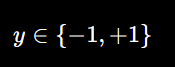

---

### SVR

No conversion.

```
250000
430000
19.5
7.2
```

---

# 3. Prediction Function

Exactly the same.

Both compute

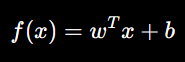

---

### SVM

```
Score = wTx+b

↓

Threshold at 0

↓

Class
```

---

### SVR

```
Prediction = wTx+b

↓

Return value directly
```

No threshold.

---

# 4. Margin

## SVM

Margin is around the separating hyperplane.

```
+ Margin
----------------

Hyperplane

----------------
- Margin
```

Goal

```
Maximum Margin
```

---

## SVR

Margin becomes an **ε-tube**.

```
Upper Tube

-------------------

Regression Line

-------------------

Lower Tube
```

The tube has width

```
ε
```

---

# 5. Loss Function

## SVM

Uses

### Hinge Loss

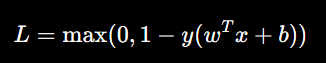

Meaning

```
Outside margin

Loss = 0

Inside margin

Loss > 0
```

---

## SVR

Uses

### ε-Insensitive Loss

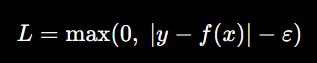

Meaning

```
Prediction inside ε tube

Loss = 0

Prediction outside ε tube

Loss > 0
```

---

# 6. Cost Function

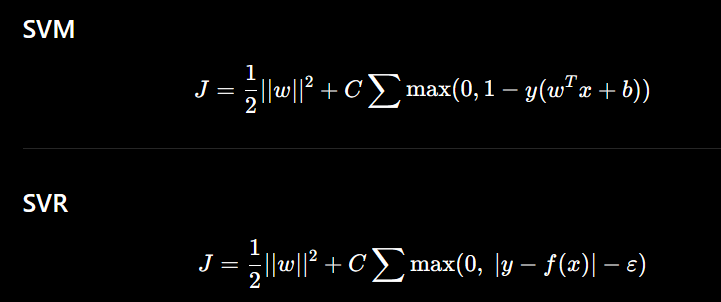

Notice

Only the loss changes.

Regularization stays exactly the same.

---

# 7. Support Vectors

## SVM

Support vectors are

```
On margin

Inside margin

Misclassified
```

---

## SVR

Support vectors are

```
Outside ε tube
```

Points inside the tube don't contribute to the loss.

---

# 8. Prediction

## SVM

```
Score

↓

Threshold

↓

0 / 1
```

---

## SVR

```
Score

↓

Return score
```

No threshold.

---

# 9. Evaluation

## SVM

```
Accuracy

Precision

Recall

ROC

F1
```

---

## SVR

```
MAE

MSE

RMSE

R²
```

---

# 10. Scratch Implementation Changes

If your SVM algorithm is:

```
Initialize w,b

↓

For every epoch

↓

For every sample

↓

Compute

z = wTx+b

↓

Compute margin

↓

Compute hinge loss

↓

Compute gradients

↓

Update w,b
```

---

SVR becomes

```
Initialize w,b

↓

For every epoch

↓

For every sample

↓

Compute

prediction = wTx+b

↓

Compute error

error = prediction - actual

↓

Compute ε-insensitive loss

↓

Compute gradients

↓

Update w,b
```

---

# Summary

| Step            | SVM                         | SVR                                 |
| --------------- | --------------------------- | ----------------------------------- |
| Target          | -1 / +1                     | Continuous values                   |
| Prediction      | (w^Tx+b) → threshold        | (w^Tx+b) directly                   |
| Margin          | Around hyperplane           | ε-tube around regression line       |
| Loss            | Hinge Loss                  | ε-Insensitive Loss                  |
| Cost Function   | Regularization + Hinge Loss | Regularization + ε-Insensitive Loss |
| Support Vectors | On/inside margin            | Outside ε-tube                      |
| Metrics         | Accuracy, F1, ROC           | MAE, MSE, RMSE, R²                  |

So, from an implementation perspective, **about 80–90% of the code structure remains the same**. The major changes are:

1. **No label conversion** (`-1/+1` is not needed).
2. **No margin check** (y(w^Tx+b)).
3. Replace **hinge loss** with **ε-insensitive loss**.
4. Derive the corresponding gradients for the new loss.
5. Return the continuous prediction instead of applying a classification threshold.


Since you've already implemented **Linear SVM from scratch**, here is the **scratch implementation structure** for **Linear SVR**. Notice how similar it is.

---

# Step 1: Prepare Dataset

No label conversion.

```text
X
y (continuous values)
```

Example

```text
House Prices

250000
315000
420000
...
```

---

# Step 2: Initialize Parameters

Initialize

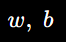

Initialize hyperparameters

* Learning Rate ((\eta))
* Epochs
* (C)
* (\varepsilon)

where

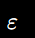

is the width of the insensitive tube.

---

# Step 3: For Every Epoch

Loop through all training samples.

---

# Step 4: Compute Prediction

For every sample

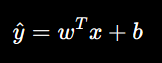

Exactly the same as SVM.

---

# Step 5: Compute Error

Instead of margin,

compute

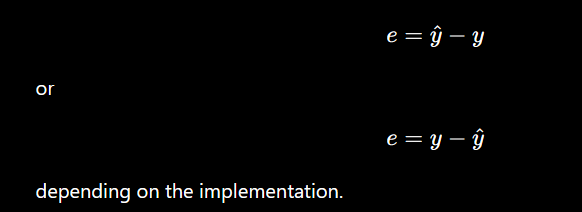

---

# Step 6: Compute ε-Insensitive Loss

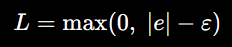

Cases

### Case 1

If

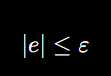

Prediction is inside the tube.

Loss

**`0`**

---

### Case 2

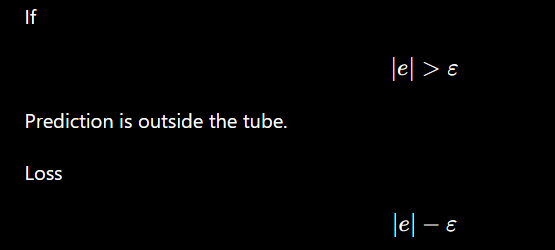

---

# Step 7: Compute Cost

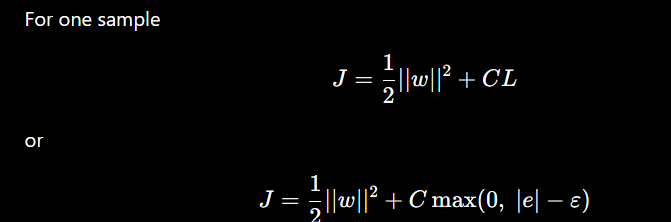

---

# Step 8: Compute Gradients

### Case 1

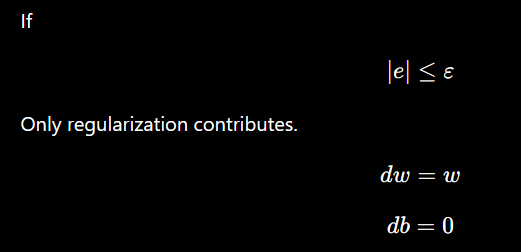

---

### Case 2

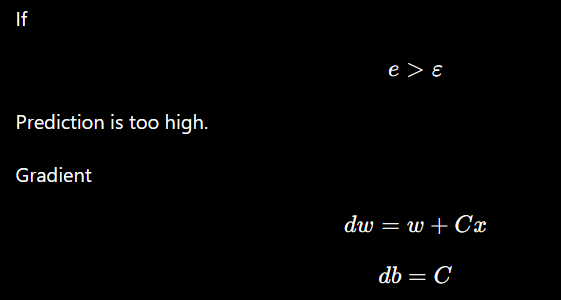

---

### Case 3

If

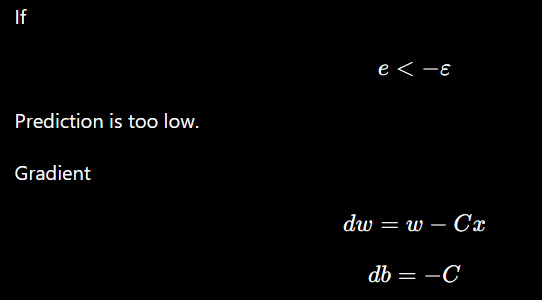

---

# Step 9: Update Parameters

Exactly the same.

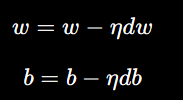

---

# Step 10: Repeat

Repeat for all epochs.

---

# Step 11: Prediction

Simply return

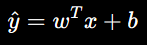

No threshold.

No sign.

No conversion.

---

# Complete Flow

```text
Initialize w,b

↓

For each epoch

↓

For each sample

↓

Compute

ŷ = wTx + b

↓

Compute error

e = ŷ − y

↓

Compute

Loss = max(0, |e| − ε)

↓

Compute Cost

↓

Check

|e| ≤ ε ?

↓

Yes
    dw = w
    db = 0

No

e > ε ?

↓

Yes
    dw = w + Cx
    db = C

↓

No

e < -ε

↓

dw = w - Cx
db = -C

↓

Update w,b

↓

Next Sample

↓

Next Epoch

↓

Prediction = wTx+b
```

If you compare this with your SVM implementation, you'll notice that **almost everything remains identical**. The only major changes are:

* Replace the **margin** computation with an **error** computation.
* Replace **hinge loss** with **ε-insensitive loss**.
* Use three gradient cases based on the error instead of two cases based on the margin.
* Return the continuous prediction directly instead of applying a classification threshold.


**(\varepsilon) is not calculated from the data.** It is a **hyperparameter**, just like the learning rate or (C).

You choose it before training.

---

## What does (\varepsilon) mean?

It defines the width of the **ε-insensitive tube**.

Suppose

[
\varepsilon = 0.5
]

Then any prediction within ±0.5 of the true value is considered "good enough" and incurs **zero loss**.

Example:

| Actual (y) | Prediction (\hat y) | Error (|y-\hat y|) | Loss |
|--------------|----------------------:|---------------------:|-----:|
| 10 | 10.2 | 0.2 | 0 |
| 10 | 9.7 | 0.3 | 0 |
| 10 | 11.0 | 1.0 | (1.0 - 0.5 = 0.5) |
| 10 | 8.8 | 1.2 | (1.2 - 0.5 = 0.7) |

---

## Visual idea

Suppose the regression line predicts 100.

### ε = 5

```text
95 -------------------------
          Prediction = 100
105 -------------------------
```

Any actual value between **95 and 105** produces **zero loss**.

---

## Small ε

Example

[
\varepsilon=0.1
]

Very narrow tube.

Almost every point lies outside.

More support vectors.

More sensitive to small errors.

---

## Large ε

Example

[
\varepsilon=10
]

Very wide tube.

Many points lie inside.

Fewer support vectors.

Model ignores small errors.

---

## Typical values

There is no universal best value.

Common starting values are:

| Data Scale                                |                                     Typical ε |
| ----------------------------------------- | --------------------------------------------: |
| Standardized target (mean≈0, std≈1)       |                               0.01, 0.05, 0.1 |
| General datasets                          |                                           0.1 |
| Large-valued targets (e.g., house prices) | Depends on the scale (e.g., 1000, 5000, etc.) |

---

## How is ε chosen?

Usually by **hyperparameter tuning**.

For example:

```python
epsilon = 0.01
epsilon = 0.1
epsilon = 0.5
epsilon = 1
```

Train the model with each value and choose the one that gives the best validation performance (e.g., lowest MAE or RMSE).

---

## Relationship with C

* **(C)** controls **how strongly** the model penalizes errors **outside** the ε-tube.
* **(\varepsilon)** controls **how wide** the no-penalty region is.

Think of it like this:

* **ε** answers: *"How much prediction error am I willing to ignore?"*
* **C** answers: *"If the error is larger than ε, how strongly should I penalize it?"*

So they control different aspects of the model.
